In [3]:
import math
math.exp(-0.5)

0.6065306597126334

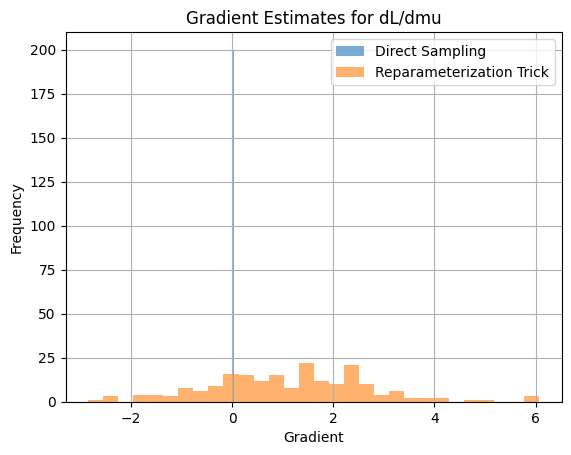

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

mu = torch.tensor([0.5], requires_grad=True)
logvar = torch.tensor([-0.5], requires_grad=True)

num_samples = 200
grads_direct = []
grads_reparam = []

def loss_fn(z):
    return z.pow(2).mean()

# Direct sampling
for _ in range(num_samples):
    mu_ = mu.clone().detach().requires_grad_(True)
    logvar_ = logvar.clone().detach().requires_grad_(True)
    std = torch.exp(0.5 * logvar_)
    z = torch.normal(mu_, std)
    loss = loss_fn(z)
    loss.backward()
    grads_direct.append(mu_.grad.item())

# Reparameterized sampling
for _ in range(num_samples):
    mu_ = mu.clone().detach().requires_grad_(True)
    logvar_ = logvar.clone().detach().requires_grad_(True)
    std = torch.exp(0.5 * logvar_)
    eps = torch.randn_like(std)
    z = mu_ + std * eps
    loss = loss_fn(z)
    loss.backward()
    grads_reparam.append(mu_.grad.item())

# Plot results
plt.hist(grads_direct, bins=30, alpha=0.6, label='Direct Sampling')
plt.hist(grads_reparam, bins=30, alpha=0.6, label='Reparameterization Trick')
plt.title('Gradient Estimates for dL/dmu')
plt.xlabel('Gradient')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()